<a href="https://colab.research.google.com/github/jetbolima/2025_steam_dataset_analysis/blob/main/(Cleaned)_Token_and_Word_Count_per_Review_within_Scope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jethro Elijah F. Bolima

This Google Colab notebook is heavily truncated vs my main project. I mostly use Jupyter Notebook but I only have 4 gb VRAM. I finished finetuning a transformer locally but I want to check out the other transformers as well. So, I am looking for free VRAM sources and this notebook is only for the finetuning and creation of text embeddings part of my main project.

In [ ]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
#import psycopg
#from pgvector.psycopg import register_vector
import os
import matplotlib.pyplot as plt
import gc
from joblib import dump, load
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Finetuning transformers for encoding

In [ ]:
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss, BatchAllTripletLoss, BatchHardTripletLoss
from sentence_transformers.losses.BatchHardTripletLoss import BatchHardTripletLossDistanceFunction
from datasets import Dataset
import torch

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier # Faster than RF
from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, PrecisionRecallDisplay, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
#from bertopic.vectorizers import ClassTfidfTransformer
import scipy.sparse as sp
#import optuna
import shap

# SVC is avoided due to the high-cardinality of the dataset
# CategoricalNB is avoided due to floating datatype of the distances

### Token Count and Binning

In [ ]:
review_text_resampled_forEmbedding = pd.read_parquet("/content/drive/MyDrive/For_Colab_GPU_use/1. SentenceTransformer - BGE-small/review_text_resampled.parquet")

In [ ]:
review_text_resampled_forEmbedding = review_text_resampled_forEmbedding[["review_text", "voted_up"]]
review_text_resampled_forEmbedding["voted_up"] = review_text_resampled_forEmbedding["voted_up"].map({True : 1, False : 0})
review_text_resampled_forEmbedding.rename(columns = {"review_text" : "text", "voted_up" : "label"}, inplace = True)
review_text_resampled_forEmbedding.head()

,text,label
0,One of the best co-op experiences ever....\r\n...,1
1,"As a standalone chapter, its a bit short on re...",1
2,Cool little puzzle game!\nPortal is a small ga...,1
3,"Unfortunately it's a dead game, even on weeken...",1
4,"It was difficult at first, repeatedly switchin...",1


In [ ]:
model = SentenceTransformer("BAAI/bge-m3", device = "cuda")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
tokenizer = model.tokenizer

def count_tokens(texts, batch_size = 1024):
  all_counts = []
  texts = texts.tolist()

  for i in range(0, len(texts), batch_size):
    end = min(i + batch_size, len(texts))
    batch = texts[i : end]

    encoded = tokenizer(batch, add_special_tokens = True, padding = False, truncation = False, return_attention_mask = False, return_token_type_ids = False, verbose = False)
    all_counts.extend(len(ids) for ids in encoded["input_ids"])
    print(f"batch {i} - {end} finished!")

  return all_counts

In [ ]:
review_text_resampled_forEmbedding["token_count"] = count_tokens(review_text_resampled_forEmbedding["text"])

bins = [0, 128, 256, 512, 1024, np.inf]
bin_labels = ["<=128", "129-256", "257-512", "513-1024", ">1024"]

review_text_resampled_forEmbedding["token_bin"] = pd.cut(review_text_resampled_forEmbedding["token_count"], bins = bins, labels = bin_labels)


print(review_text_resampled_forEmbedding["token_bin"].value_counts().sort_index())

batch 0 - 1024 finished!
batch 1024 - 2048 finished!
batch 2048 - 3072 finished!
batch 3072 - 4096 finished!
batch 4096 - 5120 finished!
batch 5120 - 6144 finished!
batch 6144 - 7168 finished!
batch 7168 - 8192 finished!
batch 8192 - 9216 finished!
batch 9216 - 10240 finished!
batch 10240 - 11264 finished!
batch 11264 - 12288 finished!
batch 12288 - 13312 finished!
batch 13312 - 14336 finished!
batch 14336 - 15360 finished!
batch 15360 - 16384 finished!
batch 16384 - 17408 finished!
batch 17408 - 18432 finished!
batch 18432 - 19456 finished!
batch 19456 - 20480 finished!
batch 20480 - 21504 finished!
batch 21504 - 22528 finished!
batch 22528 - 23552 finished!
batch 23552 - 24576 finished!
batch 24576 - 25600 finished!
batch 25600 - 26624 finished!
batch 26624 - 27648 finished!
batch 27648 - 28672 finished!
batch 28672 - 29696 finished!
batch 29696 - 30720 finished!
batch 30720 - 31744 finished!
batch 31744 - 32768 finished!
batch 32768 - 33792 finished!
batch 33792 - 34816 finished!
ba

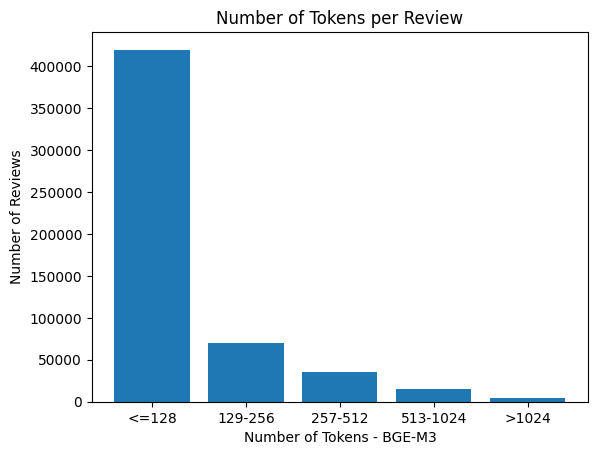

In [ ]:
counts = review_text_resampled_forEmbedding["token_bin"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel("Number of Tokens - BGE-M3")
plt.ylabel("Number of Reviews")
plt.title("Number of Tokens per Review")
plt.show()

### Word Count and Binning

In [ ]:
review_text_resampled_forEmbedding = pd.read_parquet("/content/drive/MyDrive/For_Colab_GPU_use/1. SentenceTransformer - BGE-small/review_text_resampled.parquet")

In [ ]:
review_text_resampled_forEmbedding = review_text_resampled_forEmbedding[["review_text", "voted_up"]]
review_text_resampled_forEmbedding["voted_up"] = review_text_resampled_forEmbedding["voted_up"].map({True : 1, False : 0})
review_text_resampled_forEmbedding.rename(columns = {"review_text" : "text", "voted_up" : "label"}, inplace = True)
review_text_resampled_forEmbedding.head()

,text,label
0,One of the best co-op experiences ever....\r\n...,1
1,"As a standalone chapter, its a bit short on re...",1
2,Cool little puzzle game!\nPortal is a small ga...,1
3,"Unfortunately it's a dead game, even on weeken...",1
4,"It was difficult at first, repeatedly switchin...",1


In [ ]:
review_text_resampled_forEmbedding["word_count"] = review_text_resampled_forEmbedding["text"].str.split().str.len()

bins = [0, 128, 256, 512, 1024, np.inf]
bin_labels = ["<=128", "129-256", "257-512", "513-1024", ">1024"]

review_text_resampled_forEmbedding["word_bin"] = pd.cut(review_text_resampled_forEmbedding["word_count"], bins = bins, labels = bin_labels)


print(review_text_resampled_forEmbedding["word_bin"].value_counts().sort_index())

word_bin
<=128       456118
129-256      53154
257-512      25204
513-1024      8813
>1024         1441
Name: count, dtype: int64


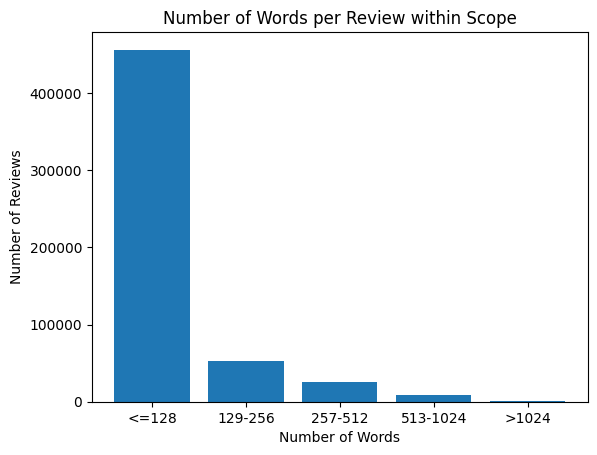

In [ ]:
counts = review_text_resampled_forEmbedding["word_bin"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Number of Words per Review within Scope")
plt.show()